# Multimodal In-Context Learning with Open-Source Models

This notebook demonstrates how to perform few-shot (in-context) learning for image classification using several popular open-source multimodal models.

We will perform the following steps:
1.  **Install Libraries**: Install all required packages from `requirements.txt`.
2.  **Load Datasets**: Load four different image datasets: Flower102, Oxford-IIIT Pets, CIFAR-10, and DTD (Describable Textures Dataset).
3.  **Load Models**: Set up functions to load the following models from Hugging Face in 4-bit precision:
    *   LLaVA 1.5 (7B)
    *   Gemma3 (12B) - Representing the Gemma family.
    *   BakLLaVA (Mistral 7B Base)
    *   Qwen-VL
4.  **Run In-Context Learning**: For a given dataset, we will show the model a few example images and their labels, then ask it to classify a new, unseen image.

## 1. Setup and Installation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('./pipeline')

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ["TORCH_USE_CUDA_DSA"] = "1" # CUDA debug mode
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import gc

# Completely reset CUDA
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

print(f"Available GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)} - {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")

import torchvision
from torchvision.datasets import Flowers102, OxfordIIITPet, CIFAR10, DTD
from torchvision import transforms as T
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig, Gemma3ForConditionalGeneration,Qwen2VLForConditionalGeneration
from PIL import Image
import requests
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import transformers
import traceback
from episode_utils import create_and_save_episode_indices, load_episode_from_indices

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Transformers version: {transformers.__version__}")

Available GPUs: 1
GPU 0: NVIDIA TITAN RTX - 23.64 GB
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Transformers version: 4.57.6


In [3]:
!pip install -U bitsandbytes
!pip show bitsandbytes

Name: bitsandbytes
Version: 0.49.2
Summary: k-bit optimizers and matrix multiplication routines.
Home-page: https://github.com/bitsandbytes-foundation/bitsandbytes
Author: 
Author-email: Tim Dettmers <dettmers@cs.washington.edu>
License-Expression: MIT
Location: /mnt/homeGPU/cquiles/ICL/ICL/research-explain/lib/python3.10/site-packages
Requires: numpy, packaging, torch
Required-by: 


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Set a seed for reproducibility
set_seed(42)

## 2. Load Datasets

Here we'll load the four datasets. We'll use `torchvision.datasets` which makes it easy to download and access them. We'll also create a simple utility to display images and their labels.

Loading Flower102...
Loading OxfordPets...
Loading CIFAR-10...
Loading DTD...
All datasets loaded.


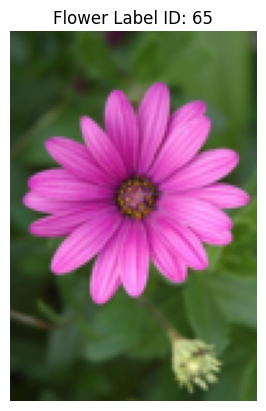

In [5]:
import torch
import torchvision.transforms.functional as F
from torchvision import transforms

class ResizeToWidth:
    def __init__(self, target_width):
        self.target_width = target_width

    def __call__(self, img):
        # Determine current width and height
        # If input is a Tensor (C, H, W)
        if isinstance(img, torch.Tensor):
            _, h, w = img.shape
        # If input is a PIL Image (W, H)
        else:
            w, h = img.size

        # Calculate new height maintaining aspect ratio
        target_height = int(h * (self.target_width / w))

        # Resize using the functional API
        # Note: F.resize expects (h, w) for the size argument
        return F.resize(img, [target_height, self.target_width], antialias=True)

def load_datasets(data_dir='./data'):
    """Downloads and loads all four datasets."""
    datasets = {}
    transform = T.Compose([
        #T.Resize((112, 112)),
        T.ToTensor(),
        ResizeToWidth(target_width=96), # Your custom transform
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    print("Loading Flower102...")
    datasets['flowers'] = Flowers102(root=data_dir, split='train', download=True, transform=transform)
    # Note: Flower102 labels are 0-101. For simplicity, we'll just show the label ID.

    print("Loading OxfordPets...")
    datasets['pets'] = OxfordIIITPet(root=data_dir, split='trainval', download=True, transform=transform)
    datasets['pets_classes'] = datasets['pets'].classes

    print("Loading CIFAR-10...")
    datasets['cifar10'] = CIFAR10(root=data_dir, train=True, download=True, transform=transform)
    datasets['cifar10_classes'] = datasets['cifar10'].classes

    print("Loading DTD...")
    datasets['dtd'] = DTD(root=data_dir, split='train', download=True, transform=transform)
    datasets['dtd_classes'] = datasets['dtd'].classes

    print("All datasets loaded.")
    return datasets

datasets = load_datasets()

def unnormalize(tensor, mean, std):
    """Un-normalizes a tensor image with mean and standard deviation."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

def show_image(image_tensor, title=''):
    """Displays a single image tensor."""
    # Un-normalize the image tensor
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image_tensor = unnormalize(image_tensor.clone(), mean, std) # Use clone to avoid modifying the original tensor

    if isinstance(image_tensor, torch.Tensor):
        image = T.ToPILImage()(image_tensor)
    else:  # Already a PIL image
        image = image_tensor
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()# Example: Show a random image from the Flowers dataset
sample_idx = random.randint(0, len(datasets['flowers']) - 1)
image, label = datasets['flowers'][sample_idx]
show_image(image, title=f"Flower Label ID: {label}")

## 3. Model Loading

We'll define a function to load a multimodal model and its processor from Hugging Face. We're using `BitsAndBytesConfig` to load the models in 4-bit precision, which significantly reduces memory usage and makes it possible to run these large models on consumer GPUs.

In [6]:
# from google.colab import userdata
# from huggingface_hub import login

# # 1. Recuperar la clave de los Secrets de Colab
# hf_token = userdata.get('hugging')

# # 2. Autenticarse en Hugging Face
# login(hf_token)

# # Ahora ya puedes cargar el modelo
# print("Login exitoso. Ya puedes cargar Gemma.")

In [7]:
MODEL_IDS = {
    "llava": "llava-hf/llava-1.5-7b-hf",
    "gemma3": "google/gemma-3-12b-it",
    #"gemma3": "google/gemma-3-4b-it",
    "bakllava": "llava-hf/bakLlava-v1-hf",
    "qwen-vl": "Qwen/Qwen2-VL-7B-Instruct",
}

g_model = None
g_processor = None

def load_model_globally(model_name):
    """Loads a specified model and its processor into global variables."""
    global g_model, g_processor

    # Liberar memoria antes de cargar
    torch.cuda.empty_cache()
    gc.collect()
    
    model_id = MODEL_IDS.get(model_name.lower())
    if not model_id:
        raise ValueError(
            f"Unknown model: {model_name}. Available models: {list(MODEL_IDS.keys())}"
        )

    print(f"Loading model: {model_id}...")

    # if "gemma" in model_name.lower():
    #     quantization_config = BitsAndBytesConfig(
    #       load_in_4bit=True,
    #       bnb_4bit_compute_dtype=torch.bfloat16
    #     )

    #     g_model = Gemma3ForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.bfloat16, quantization_config=quantization_config).to("cuda")
    if "gemma" in model_name.lower():
        # 4-bit quantization para ahorrar memoria
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )

        # device_map="auto" distribuye entre GPUs automáticamente
        g_model = Gemma3ForConditionalGeneration.from_pretrained(
            model_id, 
            torch_dtype=torch.bfloat16, 
            quantization_config=quantization_config,
            device_map="auto",  # Distribuye automáticamente
            low_cpu_mem_usage=True,
    )
        
    elif "qwen2-vl" in model_name.lower() or "qwen-vl" in model_name.lower():
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
        )
        # Qwen requires trusting remote code
        trust_remote_code = "qwen" in model_name.lower()

        g_model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_id,
            quantization_config=quantization_config,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=trust_remote_code,
        )


    g_processor = AutoProcessor.from_pretrained(model_id)
    print(f"Model {model_id} loaded successfully.")
    print_gpu_memory()

def print_gpu_memory():
    """Imprime uso de memoria en GPUs."""
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / 1024**3
        reserved = torch.cuda.memory_reserved(i) / 1024**3
        total = torch.cuda.get_device_properties(i).total_memory / 1024**3
        free = total - allocated
        print(f"GPU {i}: Allocated={allocated:.2f}GB | Reserved={reserved:.2f}GB | Free={free:.2f}GB / {total:.2f}GB")

In [8]:
# load_model_globally("qwen2-vl") # Load Qwen VL
load_model_globally("gemma3") # Load Gemma 3

`torch_dtype` is deprecated! Use `dtype` instead!


Loading model: google/gemma-3-12b-it...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model google/gemma-3-12b-it loaded successfully.
GPU 0: Allocated=7.26GB | Reserved=11.39GB | Free=16.38GB / 23.64GB


## 4. In-Context Learning for Image Classification

This is the core of the notebook. We'll create a function `run_few_shot_inference` that constructs a prompt for a model.

The prompt will contain:
*   A general instruction (e.g., "Classify the following image.")
*   A few "shots" or examples, where each shot is an image paired with its correct label.
*   The final query image that we want the model to classify.

The prompt structure is critical and can differ between models. LLaVA-style models use `<image>` tokens in the text, while PaliGemma has a simpler `\n` separated format.

In [9]:
#!pip install qwen-vl-utils

In [10]:
import random
from collections import defaultdict

def build_class_index_map(dataset):
    """
    Creates a dictionary mapping class_id -> list of indices.
    Assumes dataset has a .targets or .labels attribute (common in Torchvision).
    """
    class_indices = defaultdict(list)

    # Try to access targets directly (O(1)) - works for CIFAR, MNIST, ImageFolder
    if hasattr(dataset, 'targets'):
        targets = dataset.targets
        # Handle case where targets is a tensor
        if hasattr(targets, 'tolist'):
            targets = targets.tolist()

        for idx, label in enumerate(targets):
            class_indices[label].append(idx)

    # Fallback: Iterate dataset (O(N)) - slower, but universal
    else:
        for idx in range(len(dataset)):
            _, label = dataset[idx]
            class_indices[label].append(idx)

    return class_indices

def select_w_images_from_class(class_indices_map, class_id, w_count, exclude_indices=None):
    """
    Selects W images from a specific class, avoiding specific indices.

    Args:
        class_indices_map (dict): The map built by build_class_index_map.
        class_id (int): The target class ID.
        w_count (int): Number of images to select.
        exclude_indices (set): Indices to avoid (e.g., those already used for shots).

    Returns:
        list: Selected indices.
    """
    if exclude_indices is None:
        exclude_indices = set()

    # Filter candidates: belong to class AND not in excluded list
    candidates = [
        idx for idx in class_indices_map[class_id]
        if idx not in exclude_indices
    ]

    if len(candidates) < w_count:
        raise ValueError(f"Not enough images in class {class_id}. Requested {w_count}, found {len(candidates)}.")

    selected_indices = random.sample(candidates, w_count)
    return selected_indices
    
def select_n_way_k_shot(dataset, class_indices_map, num_classes, num_shots, num_queries, class_names=None):
    """
    Selects X shots for Y classes, and W query images.

    Args:
        dataset: The pytorch dataset.
        class_indices_map: The dict returned by build_class_index_map.
        num_classes (Y): Number of classes to sample (N-way).
        num_shots (X): Number of support images per class (K-shot).
        num_queries (W): Number of query images per class.
        class_names: Optional list of string names for classes.

    Returns:
        dict: Contains 'support_set', 'query_set', and 'selected_classes'.
    """

    available_classes = list(class_indices_map.keys())

    # 1. Select Y classes randomly
    selected_class_ids = random.sample(available_classes, num_classes)

    support_indices = []
    query_indices = []

    # To ensure we don't pick the same image for support and query
    used_indices = set()

    # 2. For each selected class, pick X shots (Support Set)
    for class_id in selected_class_ids:
        # Use the helper method
        shots = select_w_images_from_class(
            class_indices_map,
            class_id,
            num_shots,
            exclude_indices=used_indices
        )

        support_indices.extend(shots)
        used_indices.update(shots)

    # 3. Select Query images (W)
    # Usually queries come from the same Y classes to test classification.
    # If you need queries from 'not Y', you can modify the loop below to sample from diff classes.
    for class_id in selected_class_ids:
        queries = select_w_images_from_class(
            class_indices_map,
            class_id,
            num_queries,
            exclude_indices=used_indices
        )

        query_indices.extend(queries)
        used_indices.update(queries)

    # 4. Retrieve actual data objects
    # Note: Depending on your generic dataset, this might return (img, label) tuple
    support_set = [dataset[i] for i in support_indices]
    query_set = [dataset[i] for i in query_indices]

    # Get string names if provided
    selected_names = [class_names[i] for i in selected_class_ids] if class_names else selected_class_ids

    return {
        "support_indices": support_indices, # List of indices [class1_shot1...class1_shotX, class2_shot1...]
        "query_indices": query_indices,     # List of indices
        "support_set": support_set,         # List of actual data items
        "query_set": query_set,             # List of actual data items
        "classes": selected_names           # The classes chosen
    }


def select_episode_with_outliers(
    dataset,
    class_indices_map,
    num_classes,        # N-way (Support classes)
    num_shots,          # K-shot (Support images per class)
    num_queries,        # W queries (In-distribution images per class)
    num_outlier_classes=0, # How many totally new classes to add to query
    num_outlier_queries=0, # How many images per new class
    class_names=None
):
    """
    Generates an episode where the Query set contains images from the Support classes
    PLUS images from completely different classes (Out-of-Distribution).
    """

    available_classes = list(class_indices_map.keys())

    # 1. Safety Check
    if num_classes + num_outlier_classes > len(available_classes):
        raise ValueError(f"Dataset has {len(available_classes)} classes, but you requested {num_classes} support + {num_outlier_classes} outliers.")

    # 2. Select Support Classes (The 'Y' classes)
    selected_support_classes = random.sample(available_classes, num_classes)

    # 3. Select Outlier Classes (The 'Not Y' classes) from the remaining pool
    remaining_classes = [c for c in available_classes if c not in selected_support_classes]
    selected_outlier_classes = random.sample(remaining_classes, num_outlier_classes)

    support_indices = []
    query_indices = []
    used_indices = set() # To prevent overlap

    # --- PHASE A: Process Support Classes (Y) ---
    for class_id in selected_support_classes:
        # A.1 Select Support Images (K shots)
        shots = select_w_images_from_class(
            class_indices_map, class_id, num_shots, exclude_indices=used_indices
        )
        support_indices.extend(shots)
        used_indices.update(shots)

        # A.2 Select In-Distribution Query Images (W queries)
        queries = select_w_images_from_class(
            class_indices_map, class_id, num_queries, exclude_indices=used_indices
        )
        query_indices.extend(queries)
        used_indices.update(queries)

    # --- PHASE B: Process Outlier Classes (Not Y) ---
    for class_id in selected_outlier_classes:
        # B.1 Select Outlier Query Images
        # Note: We don't select support shots for these!
        outlier_queries = select_w_images_from_class(
            class_indices_map, class_id, num_outlier_queries, exclude_indices=used_indices
        )
        query_indices.extend(outlier_queries)
        used_indices.update(outlier_queries)

    # 4. Retrieve Data
    support_set = [dataset[i] for i in support_indices]
    query_set = [dataset[i] for i in query_indices]

    # Resolve names for display
    if class_names:
        support_class_names = [class_names[i] for i in selected_support_classes]
        outlier_class_names = [class_names[i] for i in selected_outlier_classes]
    else:
        support_class_names = selected_support_classes
        outlier_class_names = selected_outlier_classes

    return {
        "support_indices": support_indices,
        "query_indices": query_indices,
        "support_set": support_set,
        "query_set": query_set,
        "support_classes": support_class_names, # The main classes
        "outlier_classes": outlier_class_names, # The extra classes
    }


In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import math

def visualize_episode(data, all_class_names=None):
    """
    Displays the Support Set and Query Set from the episode data.

    Args:
        data (dict): The dictionary returned by select_n_way_k_shot.
        all_class_names (list/dict): The global list mapping class_id -> name.
                                     If None, numerical IDs are displayed.
    """

    def convert_to_displayable(img):
        """Converts PyTorch Tensors to Numpy arrays for plotting."""
        if isinstance(img, torch.Tensor):
            # If (C, H, W), convert to (H, W, C)
            if img.shape[0] == 3 or img.shape[0] == 1:
                img = img.permute(1, 2, 0)

            img = img.numpy()

            # Un-normalize if necessary (simple heuristic: if min < 0)
            if img.min() < 0:
                img = (img - img.min()) / (img.max() - img.min())

        return img

    def plot_grid(dataset_items, title):
        count = len(dataset_items)
        if count == 0:
            print(f"No images in {title}")
            return

        # Calculate grid dimensions (approx square)
        cols = 5
        rows = math.ceil(count / cols)

        plt.figure(figsize=(3 * cols, 3.5 * rows))
        plt.suptitle(title, fontsize=16, y=1.02)

        for i, (img, label) in enumerate(dataset_items):
            plt.subplot(rows, cols, i + 1)

            # Handle image format
            display_img = convert_to_displayable(img)
            plt.imshow(display_img, cmap='gray' if display_img.ndim==2 else None)

            # Get Label Name
            label_text = str(label)
            if all_class_names and label < len(all_class_names):
                label_text = f"{all_class_names[label]}\n(ID: {label})"

            plt.title(label_text, fontsize=10)
            plt.axis('off')

        plt.tight_layout()
        plt.show()

    # --- Main Display Logic ---
    #print(f"Episode Classes: {data['classes']}")

    # 1. Display Support Set
    plot_grid(data['support_set'], title="Support Set (Few-Shot Examples)")

    # 2. Display Query Set
    plot_grid(data['query_set'], title="Query Set (Evaluation Images)")

In [12]:
# 1. Setup (Run this once)
dataset_name = "flowers" # e.g. 'cifar10'
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")

# Build the index map once to make subsequent sampling fast
index_map = build_class_index_map(dataset)

# 2. Configuration for the Episode
N_WAY = 5      # Y: Number of classes
K_SHOT = 5     # X: Number of shots per class
W_QUERY = 1   # W: Number of query images per class

# 3. Run Selection
data = select_n_way_k_shot(
    dataset=dataset,
    class_indices_map=index_map,
    num_classes=N_WAY,
    num_shots=K_SHOT,
    num_queries=W_QUERY,
    class_names=all_class_names
)

print(f"Selected Classes: {data['classes']}")
print(f"Support Set Size: {len(data['support_set'])}") # Should be N_WAY * K_SHOT
print(f"Query Set Size: {len(data['query_set'])}")     # Should be N_WAY * W_QUERY

#visualize_episode(data, all_class_names=all_class_names)
# Accessing the data
# support_images = [item[0] for item in data['support_set']]
# support_labels = [item[1] for item in data['support_set']]

Selected Classes: [14, 3, 94, 35, 31]
Support Set Size: 25
Query Set Size: 5


In [13]:
# Configuration
N_WAY = 5           # 5 classes in the support set
K_SHOT = 5          # 5 images each
W_QUERY = 1        # 10 test images for the "correct" classes

# Outliers
N_OUTLIERS = 2      # 2 extra classes that are NOT in the support set
W_OUTLIERS = 1      # 1 images for each outlier class

data = select_episode_with_outliers(
    dataset=dataset,
    class_indices_map=index_map,
    num_classes=N_WAY,
    num_shots=K_SHOT,
    num_queries=W_QUERY,
    num_outlier_classes=N_OUTLIERS,
    num_outlier_queries=W_OUTLIERS,
    class_names=all_class_names
)

print(f"Support Classes: {data['support_classes']}")
print(f"Outlier Classes: {data['outlier_classes']}")

# You can use the visualize_episode method I gave you previously
# to see the results. It will automatically show the new labels
# in the Query grid.
#visualize_episode(data, all_class_names=all_class_names)

Support Classes: [35, 18, 27, 97, 43]
Outlier Classes: [13, 11]


In [14]:
# 1. Your global list of class names (e.g., from CIFAR10, ImageNet, etc.)
# If you don't have names, pass None, and it will show the ID number.
global_class_names = datasets.get(f"{dataset_name}_classes")

# 2. Call the function with the data dictionary
#visualize_episode(data, all_class_names=global_class_names)

In [15]:
TEST_PROMPT_CLASSIFICATION = "You are a classifier. Using the example images and labels provided above. Output the label of this new image in format XML <response>label</response> "
TEST_PROMPT_CLASSIFICATION2 =  """
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response>
"""
TEST_PROMPT_CLASSIFICATION_FEATURES = "Using the images and classes provided above. Which features you will use for creating a classifier?"
TEST_PROMPT_CLASSIFICATION_AND_RULE_BASED = """
You are working on XAI (Explainable AI) and ICL (In-Context Learning).
Create a prompt for Rule-Based Learning to classfiy images with these features and classify the image:
"""
TEST_PROMPT_CLASSIFICATION_AND_RULE_BASED2 = """
EXTRICTILY using the images and classes provided above.
You are working on XAI (Explainable AI) and ICL (In-Context Learning).
TASK: Design an structured prompt for making a multimodal model act as a Rule-Based Classifier. Use the images and classes provided in the context window. This prompt should use the Chain of Thought (CoT) to force the model to extract features before choosing the class.
First, determine the features of the dataset and write the Feature Extration Protocol according to the classes and images provided in the context
Second, extract the label classes included in the images attached (ICL)
Third, complete the Knowledge Base according to the classes and images provided in the context. Add as many classes you have in the few-shot examples. Use the sample labels.
Four, determine the Decision logic according to the classes and images provided in the context. Add as many decision logic items you need for covering all the classes.

ADAPT THIS EXAMPLE TO THE CLASS NAMES AND NUMBER OF CLASSES PROVIDED AT START:

# Role
You are an Explainable AI (XAI) Vision Agent specialized in Rule-Based Classification of geometric shapes.

# Task
Analyze the provided image and classify it based strictly on the extracted features and the defined Rule Set.

# Feature Extraction Protocol
First, scan the image and determine the values for the following variables. Output this as a "Feature Vector":
1.  **Dominant_Color**: (e.g., Red, Yellow, Blue).
2.  **Shape_Type**: (e.g., Square, Circle, Triangle).
3.  **Vertex_Count**: (Integer value of visible corners).
4.  **Circularity**: (High for circles, Low for angular shapes).

# Knowledge Base (Training Data)
Use these known classes as your ground truth:
* **CLASS A**:
    * IF Color == Red AND Shape == Square (Vertex_Count == 4).
* **CLASS B**:
    * IF Color == Yellow AND Shape == Circle (Vertex_Count == 0).


# Decision Logic (Rule-Based)
Apply the following logic to the extracted features:
1.  Check if the image perfectly matches the rules for CLASS A.
2.  Check if the image perfectly matches the rules for CLASS B.
3.  **Conflict Resolution**: If the image shares features from different classes (e.g., Color of B but Shape of A), classify it as a "Hybrid" or "New Class" and explicitly explain which feature comes from which parent class.

# Output Format
Please provide your response in this structure:
1.  **Visual Reasoning**: (The extracted feature vector).
2.  **Rule Check**: (Step-by-step comparison against Class A and Class B rules).
3.  **Final Classification**: (The class label).
4.  **Explanation**: (A single sentence justifying the decision based on the features).


"""

TEST_PROMPT_CLASSIFICATION_WITH_AXIOMS = """
You are an expert Neuro-Symbolic Reasoner and Ontologist.
Your task is to classify the provided image based STRICTLY on a set of defined Ontological Axioms.
Do not rely on your internal statistical intuition for classification. You must deduce the class using logic.

### 1. The Knowledge Base (TBox)
Here are the Axioms defining the valid classes in this domain.
(Note: 'EquivalentTo' implies necessary and sufficient conditions).

{axioms_list}
* Example Format: Class Zebra EquivalentTo (hasTexture value Stripes AND hasBodyShape value HorseLike)

### 2. Reasoning Protocol
For the input image, perform the following steps:

Step A: Visual Primitive Extraction (ABox Assertion)
- List ONLY the observable visual features present in the image (e.g., shapes, colors, textures, parts).
- Do not infer the class yet. Just state the visual facts.

Step B: Axiom Satisfaction Check
- For each Class defined in the TBox, check if the extracted visual primitives satisfy the axiom conditions.
- If a condition is NOT met, explicitly state which part of the axiom failed (e.g., "Fails Zebra axiom: Stripes are missing").

Step C: Disjointness & Consistency
- Ensure the object does not satisfy the definitions of two Disjoint Classes simultaneously (unless one is a subclass of the other).

Step D: Final Classification
- Conclude the class based on the satisfied axiom.

---
Input Image: {image_input}
Response:
"""


In [16]:
import torch
import torchvision.transforms as T
from qwen_vl_utils import process_vision_info
import itertools

def select_few_shot_images(num_shots, dataset_name):
    dataset = datasets[dataset_name]
    class_names = datasets.get(f"{dataset_name}_classes")

    indices = random.sample(range(len(dataset)), num_shots +1)
    shots = [dataset[i] for i in indices[:num_shots]]
    query = dataset[indices[num_shots]]

    return indices, shots, query, class_names


def select_few_shot_images_with_data(data, index):
    dataset = datasets[dataset_name]
    class_names = datasets.get(f"{dataset_name}_classes")
    indices = data['support_indices']+[data['query_indices'][index]]
    shots = [dataset[i] for i in data['support_indices']]
    query = dataset[data['query_indices'][index]]
    return indices, shots, query, all_class_names

def get_few_shot_content_parts(content_parts, indices, shots, query, class_names):
    # --- 1. Common: Build the Message History ---
    # Both models accept the standard OpenAI-style [{"role":..., "content":...}] format

    # Process Few-Shot Examples
    for img_tensor, label_id in shots:
        img_pil = T.ToPILImage()(img_tensor)
        label_text = class_names[label_id] if class_names else str(label_id)

        content_parts.append({"type": "text", "text": f"label: {label_text}.\n"})
        content_parts.append({"type": "image", "image": img_pil})
        

    return content_parts

def append_query_image(content_parts, query, prompt):

    #The query is a tuple with the image and the label
    query_img_tensor = query[0]
    query_img_pil = T.ToPILImage()(query_img_tensor)
    content_parts.append({"type": "image", "image": query_img_pil})
    content_parts.append({"type": "text", "text": prompt})
    return content_parts

def get_image_text_messages(content_parts, prompt, query):
    content_parts = append_query_image(content_parts, query, prompt)
    return  content_parts

def get_messages(content_parts, prompt,indices, shots, query, class_names):

    # --- 1. Common: Build the Message History ---
    # Process Few-Shot Examples

    content_parts = get_few_shot_content_parts(content_parts, indices, shots, query, class_names)

    # Process Query Image
    content_parts = append_query_image(content_parts, query, prompt)


    return content_parts


def get_classification_messages(prompt, indices, shots, query, class_names):
    examples = list()

    examples.append({"role": "system", "content": prompt})

    for img_tensor, label_id in shots:

        img_pil = T.ToPILImage()(img_tensor)
        label_text = class_names[label_id] if class_names else str(label_id)

        content_parts = list()
        content_parts.append({"type": "image", "image": img_pil})
        content_parts.append({"type": "text", "text": "Classify this image." })

        examples.append({"role": "user", "content": content_parts})
        examples.append({"role": "assistant", "content":  f"<response>{label_text}</response>"})

    content_parts = list()
    #print(query)
    query_img_pil = T.ToPILImage()(query[0])
    content_parts.append({"type": "image", "image": query_img_pil})
    content_parts.append({"type": "text", "text": "Classify this image."})
    examples.append({"role": "user", "content": content_parts})

    return examples



In [17]:

def run_icl_inference(model, processor, model_name, messages, content_parts=None, temperature=0.2):
    """
    Runs In-Context Learning inference handling Qwen vs Gemma differences.

    Args:
        model: The loaded model (Qwen2VLForConditionalGeneration or AutoModel).
        processor: The loaded processor.
        model_name: String containing the model name (e.g. "Qwen2-VL-7B").
        shots: List of tuples (image_tensor, label_id).
        query: Tuple of (query_image_tensor, query_label_id).
        class_names: List of strings for label mapping.
    """
    try:
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    except:
        pass
     
    # --- 2. Branching Logic: Prepare Inputs ---
    # print(model_name)
    # >>> BRANCH A: QWEN2-VL <<<
    if "qwen" in model_name.lower():
        # 1. Generate text with special tokens
        text_prompt = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        # 2. Use Qwen Utils to extract images and grid configuration
        image_inputs, video_inputs = process_vision_info(messages)
        # 3. Create Inputs
        inputs = processor(
            text=[text_prompt],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",

        )

    # >>> BRANCH B: GEMMA / STANDARD <<<
    else:
        # print("Using Gemma")
        # 1. Generate text prompt
        text_prompt = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        # 2. Manually extract PIL images in order (Gemma needs a flat list)
        # We iterate through content_parts to ensure order matches the text tokens
        if content_parts:
            all_images_pil = [part["image"] for part in content_parts if part["type"] == "image"]
        else:
            content_parts = [part["content"] for part in messages if type(part["content"]) == list]
            content_parts = list(itertools.chain.from_iterable(content_parts))
            all_images_pil = [part["image"] for part in content_parts if part["type"] == "image"]

        # 3. Create Inputs
        inputs = processor(
            text=[text_prompt],
            images=all_images_pil,
            padding=True,
            return_tensors="pt",
        )

    # --- 3. Common: Inference ---
    inputs = inputs.to(model.device)
    
    # Generate
    with torch.no_grad():
        # generated_ids = model.generate(**inputs, max_new_tokens=2048, temperature=temperature)
        generated_ids = model.generate(**inputs, max_new_tokens=128, temperature=temperature)
        # generated_ids = model.generate(**inputs, max_new_tokens=256, temperature=temperature, do_sample=True,top_p=0.9)
        
    # with torch.no_grad():
    #     # CAMBIO: Greedy decoding para Gemma (sin do_sample, pero con temperatura baja)
    #     if "gemma" in model_name.lower():
    #         generated_ids = model.generate(
    #             **inputs, 
    #             max_new_tokens=256,
    #             use_cache=True
    #         )
    #     else:
    #         # Qwen usa sampling con temperatura baja
    #         generated_ids = model.generate(
    #             **inputs, 
    #             max_new_tokens=256,
    #             temperature=temperature,
    #             do_sample=True,
    #             top_p=0.9,
    #             use_cache=True
    #         )
            
    # Decode
    # We clip the input tokens to only see the new generated text
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )
    
    #Limpiar memoria
    del inputs, generated_ids, generated_ids_trimmed
    gc.collect()
    
    try:
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    except:
        pass
    
    return output_text[0]

# --- Usage Example ---
# 2. Configuration for the Episode
'''
N_WAY = 3      # Y: Number of classes
K_SHOT = 2     # X: Number of shots per class
W_QUERY = 1   # W: Number of query images per class

# 3. Run Selection
data = select_n_way_k_shot(
    dataset=dataset,
    class_indices_map=index_map,
    num_classes=N_WAY,
    num_shots=K_SHOT,
    num_queries=W_QUERY,
    class_names=all_class_names
)

print(data)
#indices, shots, query, class_names = select_few_shot_images(3, "flowers")
indices, shots, query, class_names = select_few_shot_images_with_data(data, 0)
# 1. Your global list of class names (e.g., from CIFAR10, ImageNet, etc.)
# If you don't have names, pass None, and it will show the ID number.
global_class_names = datasets.get(f"{dataset_name}_classes")

# 2. Call the function with the data dictionary
visualize_episode(data, all_class_names=global_class_names)
content_parts = list()
content_parts = get_messages(content_parts, TEST_PROMPT_CLASSIFICATION_WITH_AXIOMS,indices, shots, query, class_names)
messages = [{"role": "user", "content": content_parts}]
result = run_icl_inference(g_model, g_processor, "gemma", messages, content_parts )
print(result)

content_parts = list()
content_parts = get_image_text_messages(content_parts, result, query)
messages = [{"role": "user", "content": content_parts}]
result = run_icl_inference(g_model, g_processor, "gemma", messages, content_parts )
print(result)
'''

'\nN_WAY = 3      # Y: Number of classes\nK_SHOT = 2     # X: Number of shots per class\nW_QUERY = 1   # W: Number of query images per class\n\n# 3. Run Selection\ndata = select_n_way_k_shot(\n    dataset=dataset,\n    class_indices_map=index_map,\n    num_classes=N_WAY,\n    num_shots=K_SHOT,\n    num_queries=W_QUERY,\n    class_names=all_class_names\n)\n\nprint(data)\n#indices, shots, query, class_names = select_few_shot_images(3, "flowers")\nindices, shots, query, class_names = select_few_shot_images_with_data(data, 0)\n# 1. Your global list of class names (e.g., from CIFAR10, ImageNet, etc.)\n# If you don\'t have names, pass None, and it will show the ID number.\nglobal_class_names = datasets.get(f"{dataset_name}_classes")\n\n# 2. Call the function with the data dictionary\nvisualize_episode(data, all_class_names=global_class_names)\ncontent_parts = list()\ncontent_parts = get_messages(content_parts, TEST_PROMPT_CLASSIFICATION_WITH_AXIOMS,indices, shots, query, class_names)\nmessag

### Experimentation

## Few-shot Learning Baseline

In [18]:
TEST_PROMPT_CLASSIFICATION3 = "You are an expert image classifier. Your task is to classify the following image into one of the provided classes. Output only the class name in XML tags."

def get_classification_messages3(prompt, indices, shots, query, class_names):
    examples = list()

    # System prompt to set the context
    examples.append({"role": "system", "content": prompt})

    # Few-shot examples
    for img_tensor, label_id in shots:
        img_pil = T.ToPILImage()(img_tensor)
        label_text = class_names[label_id] if class_names else str(label_id)

        # User message with image
        user_content = [
            {"type": "image", "image": img_pil},
            {"type": "text", "text": "What is the class of this image?"}
        ]
        examples.append({"role": "user", "content": user_content})

        # Assistant response with the correct label
        assistant_content = f"<response>{label_text}</response>"
        examples.append({"role": "assistant", "content": assistant_content})

    # Query image
    query_img_tensor, _ = query
    query_img_pil = T.ToPILImage()(query_img_tensor)

    query_content = [
        {"type": "image", "image": query_img_pil},
        {"type": "text", "text": "Based on the examples, what is the class of this new image?"}
    ]
    examples.append({"role": "user", "content": query_content})

    return examples

In [19]:
### Dataset creation
import re

def pipeline(pway, pshot, pquery, dataset_name, model_name, prompt, data, debug=False):
    dataset = datasets[dataset_name]

    global_class_names = datasets.get(f"{dataset_name}_classes")


    # 2. Call the function with the data dictionary
    if debug:
        visualize_episode(data, all_class_names=global_class_names)

    total = 0
    correct = 0

    for i in range(pquery*pway):
        # print(f"Processing image {i}")
        indices, shots, query, class_names = select_few_shot_images_with_data(data,i)
        #content_parts = list()
        #content_parts = get_messages(content_parts, prompt,indices, shots, query, class_names)
        #messages = [{"role": "user", "content": content_parts}]
        messages = get_classification_messages3(TEST_PROMPT_CLASSIFICATION2, indices, shots, query, class_names)
        # print("---")
        # print(messages)
        # print("---"*10)
        #result = run_icl_inference(g_model, g_processor, model_name, messages, content_parts )
        result = run_icl_inference(g_model, g_processor, model_name, messages, None )
        del messages
        # Use regex to find the content inside <response> tags
        match = re.search(r'<response>(.*?)</response>', result)
        if match:
            label = match.group(1)
            label_id = query[1]
            label_text = class_names[label_id] if class_names else str(label_id)

            if debug:
                print(f"Extracted class: {label}")
                print("Expected: ", label_text)
                print(type(label))


            if (type(label) == int and int(label) == int(label_text)) or (type(label) == str and label.lower() == label_text.lower()):
                correct += 1
        else:
            if debug:
                print("No class found.")

        total += 1

    del data

    return total, correct




In [20]:
# !export PYTORCH_ALLOC_CONF=expandable_segments:True

In [24]:
import gc
dataset_name = "pets"

#tests = [ (5,1,5), (5,3,5), (5,5,5)]
# tests = [ (2,1,2), (5,3,2), (2,5,2), (2,5,2)]
#tests = [ (2,1,2), (2,2,2), (2,3,2)]

#pruebas de test:
#más clases pocas img TEST 1
#tests = [(2,1,2), (3,1,2), (4,1,2), (5,1,2)]

#más img pocas clases TEST 2
#tests = [(2,2,1), (2,2,2), (2,2,3), (2,2,4)]  # subir test, no train

#otra: TET 4
# tests = [(4,1,2), (3,1,2), (3,1,3), (4,1,1)]

# Lista definitiva de tests para few-shot accuracy
# Formato: (num_clases, train_per_class, test_per_class)
# Comentarios explican qué se evalúa en cada escenario

tests = [
    # ---------- 2 clases ----------
    (2,2,5),   # Total 7 img. Fácil.
    (2,2,8),   # Total 10 img. Límite máximo del dataset.
    (2,1,5),   # Total 6 img. Baseline con poca info.
    (2,1,9),   # Total 10 img. Máxima estabilidad posible con 1 shot.
    
    # ---------- 3 clases ----------
    (3,1,5),   # Total 6 img. Dificultad media.
    (3,1,9),   # Total 10 img. Test más robusto para 3 clases.

    # ---------- 4 clases ----------
    (4,1,5),   # Total 6 img. Dificultad alta (poca info, muchas clases).
    (4,1,9),   # Total 10 img. Generalización máxima en entorno difícil.
]


dataset_filenames = dict()

gen_datasets = True

if gen_datasets:

    for dataset_name in ["pets", "cifar10", "flowers", "dtd"]:
        try:
            # 1. Setup (Run this once)
            dataset = datasets[dataset_name]
            all_class_names = datasets.get(f"{dataset_name}_classes")

            # Build the index map once to make subsequent sampling fast
            index_map = build_class_index_map(dataset)

            filenames = []
            for (pway, pshot, pquery) in tests:
                episode_filepath = create_and_save_episode_indices(
                    class_indices_map=index_map,
                    num_classes=pway,
                    num_shots=pshot,
                    num_queries=pquery,
                    save_dir="episodes/"+dataset_name
                )
                filenames.append(episode_filepath)
            dataset_filenames[dataset_name] = filenames
        except:
            traceback.print_exc()
            pass
else:
    dataset_filenames["pets"] = []
    dataset_filenames["pets"].append("episodes/pets/episode_N5_K1_Q5.npy")
    dataset_filenames["pets"].append("episodes/pets/episode_N5_K3_Q5.npy")
    dataset_filenames["pets"].append("episodes/pets/episode_N5_K5_Q5.npy")
    #dataset_filenames["pets"].append("episodes/pets/episode_N10_K3_Q5.npy")
    dataset_filenames["cifar10"] = []
    dataset_filenames["cifar10"].append("episodes/cifar10/episode_N5_K1_Q5.npy")
    dataset_filenames["cifar10"].append("episodes/cifar10/episode_N5_K3_Q5.npy")
    dataset_filenames["cifar10"].append("episodes/cifar10/episode_N5_K5_Q5.npy")
    dataset_filenames["flowers"] = []
    dataset_filenames["flowers"].append("episodes/flowers/episode_N5_K1_Q5.npy")
    dataset_filenames["flowers"].append("episodes/flowers/episode_N5_K3_Q5.npy")
    dataset_filenames["flowers"].append("episodes/flowers/episode_N5_K1_Q5.npy")
    #dataset_filenames["flowers"].append("episodes/flowers/episode_N10_K3_Q5.npy")
    dataset_filenames["dtd"] = []
    dataset_filenames["dtd"].append("episodes/dtd/episode_N5_K1_Q5.npy")
    dataset_filenames["dtd"].append("episodes/dtd/episode_N5_K3_Q5.npy")
    dataset_filenames["dtd"].append("episodes/dtd/episode_N5_K5_Q5.npy")
    #dataset_filenames["dtd"].append("episodes/dtd/episode_N10_K3_Q5.npy")


Episode indices saved to: episodes/pets/episode_N2_K2_Q5.npy
Episode indices saved to: episodes/pets/episode_N2_K2_Q8.npy
Episode indices saved to: episodes/pets/episode_N2_K1_Q5.npy
Episode indices saved to: episodes/pets/episode_N2_K1_Q9.npy
Episode indices saved to: episodes/pets/episode_N3_K1_Q5.npy
Episode indices saved to: episodes/pets/episode_N3_K1_Q9.npy
Episode indices saved to: episodes/pets/episode_N4_K1_Q5.npy
Episode indices saved to: episodes/pets/episode_N4_K1_Q9.npy
Episode indices saved to: episodes/cifar10/episode_N2_K2_Q5.npy
Episode indices saved to: episodes/cifar10/episode_N2_K2_Q8.npy
Episode indices saved to: episodes/cifar10/episode_N2_K1_Q5.npy
Episode indices saved to: episodes/cifar10/episode_N2_K1_Q9.npy
Episode indices saved to: episodes/cifar10/episode_N3_K1_Q5.npy
Episode indices saved to: episodes/cifar10/episode_N3_K1_Q9.npy
Episode indices saved to: episodes/cifar10/episode_N4_K1_Q5.npy
Episode indices saved to: episodes/cifar10/episode_N4_K1_Q9.npy


In [22]:

def run_pipeline_for(model, prompt, dataset_name, debug=False):
    print(f"Running pipeline for {model}, {dataset_name}")
    print(f"PROMPT\n {prompt}\n")
    for e, (way, shot, query) in enumerate(tests):
        try:
            data = load_episode_from_indices(
                filepath=dataset_filenames[dataset_name][e],
                dataset=dataset,
                class_names=all_class_names
            )


            total, correct = pipeline( way, shot, query, dataset_name, model, prompt, data, debug)

            print(f"Experiment: {way} classes - {shot} imágenes - {query} query")
            print(f"Total: {total} , Correct: {correct}, Accuracy: {correct / total }")

            del data
            gc.collect()
        except Exception:
            # Prints the full stack trace to the console
            traceback.print_exc()



## BASELINE - Pipeline for Gemma

In [23]:
dataset_name = "flowers"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("gemma", TEST_PROMPT_CLASSIFICATION2, dataset_name)


KeyboardInterrupt: 

In [ ]:
dataset_name = "pets"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("gemma3", TEST_PROMPT_CLASSIFICATION2, dataset_name)

Running pipeline for gemma3, pets
PROMPT
 
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response>


Experiment: 2 classes - 1 imágenes - 2 query
Total: 4 , Correct: 3, Accuracy: 0.75
Experiment: 3 classes - 1 imágenes - 2 query
Total: 6 , Correct: 1, Accuracy: 0.16666666666666666
Experiment: 4 classes - 1 imágenes - 2 query
Total: 8 , Correct: 1, Accuracy: 0.125
Experiment: 5 classes - 1 imágenes - 2 query
Total: 10 , Cor

In [ ]:
dataset_name = "dtd"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("gemma3", TEST_PROMPT_CLASSIFICATION2, dataset_name)

Running pipeline for gemma3, dtd
PROMPT
 
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response>


Experiment: 2 classes - 1 imágenes - 2 query
Total: 4 , Correct: 4, Accuracy: 1.0
Experiment: 3 classes - 1 imágenes - 2 query
Total: 6 , Correct: 3, Accuracy: 0.5
Experiment: 4 classes - 1 imágenes - 2 query
Total: 8 , Correct: 2, Accuracy: 0.25
Experiment: 5 classes - 1 imágenes - 2 query
Total: 10 , Correct: 6, Accuracy: 

In [ ]:
dataset_name = "cifar10"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("gemma3", TEST_PROMPT_CLASSIFICATION2, dataset_name)

Running pipeline for gemma3, cifar10
PROMPT
 
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response>


Experiment: 2 classes - 1 imágenes - 2 query
Total: 4 , Correct: 3, Accuracy: 0.75
Experiment: 3 classes - 1 imágenes - 2 query
Total: 6 , Correct: 3, Accuracy: 0.5
Experiment: 4 classes - 1 imágenes - 2 query
Total: 8 , Correct: 6, Accuracy: 0.75
Experiment: 5 classes - 1 imágenes - 2 query
Total: 10 , Correct: 2, Accur

## BASELINE - Pipeline for Qwen

In [ ]:
dataset_name = "flowers"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("qwen-vl", TEST_PROMPT_CLASSIFICATION2, dataset_name)




Running pipeline for qwen-vl, flowers
PROMPT
 
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response> 


Processing image 0
---
[{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x76 at 0x7AF8FB2D1B70>}, {'type': 'text', 'text': 'label: 81.\n'}, {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x75 at 0x7AF8FB2D1CF0>}, {'type': 'text', 'text': 'label: 15.\n'}, {

In [ ]:
dataset_name = "pets"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("qwen-vl", TEST_PROMPT_CLASSIFICATION2, dataset_name)

Running pipeline for qwen-vl, pets
PROMPT
 
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response> 


Processing image 0
---
[{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x144 at 0x7AF9202554B0>}, {'type': 'text', 'text': 'label: Keeshond.\n'}, {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x72 at 0x7AF8FB4A7F40>}, {'type': 'text', 'text': 'label: Pomera

In [ ]:
dataset_name = "dtd"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("qwen-vl", TEST_PROMPT_CLASSIFICATION2, dataset_name)

Running pipeline for qwen-vl, dtd
PROMPT
 
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response> 


Processing image 0
---
[{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x114 at 0x7AF8FB430C70>}, {'type': 'text', 'text': 'label: meshed.\n'}, {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x97 at 0x7AF8FB4A61A0>}, {'type': 'text', 'text': 'label: cracked.\

In [ ]:
dataset_name = "cifar10"
dataset = datasets[dataset_name]
all_class_names = datasets.get(f"{dataset_name}_classes")
index_map = build_class_index_map(dataset)

run_pipeline_for("qwen-vl", TEST_PROMPT_CLASSIFICATION2, dataset_name)

Running pipeline for qwen-vl, cifar10
PROMPT
 
You are a high-precision image classifier.

Task:
1. Analyze the provided "few-shot" examples and their labels to establish the ground truth for each category. Pay close attention to distinct visual features (shapes, textures, colors, and context).
2. Examine the "Target Image".
3. Compare the Target Image strictly against the provided examples.
4. Reason step-by-step to determine which category the Target Image belongs to.

Constraints:
- Use ONLY the labels provided in the examples.
- Do not make assumptions outside the visual evidence.

Output Format:
The label of this new image in format XML <response>label</response> 


Processing image 0
---
[{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x96 at 0x7AF8FB432DD0>}, {'type': 'text', 'text': 'label: frog.\n'}, {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=96x96 at 0x7AF8FB432B30>}, {'type': 'text', 'text': 'label: cat.\n'}